# Task 2: RTL Bug Classification with GPU

Train an XGBoost classifier to detect RTL bugs (combinational loops, FSM issues, CDC problems) using AST features.

**GPU**: Tesla T4 (14.6 GB VRAM)

In [31]:
# Setup paths
import sys
from pathlib import Path

# Notebook is in notebooks/rtl_analyzer_phase3/, project root is 2 levels up
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")

Project root: /home/jovyan/silicogen/rtl_analyzer/.worktrees/phase3-algorithm
Working directory: /home/jovyan/silicogen/rtl_analyzer/.worktrees/phase3-algorithm/notebooks/rtl_analyzer_phase3


In [32]:
# Check GPU status
import torch
import xgboost as xgb

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"XGBoost: {xgb.__version__}")

PyTorch: 2.11.0+cu130, CUDA: True
GPU: Tesla T4
XGBoost: 3.2.0


In [33]:
# Load RTL fixtures
from rtl_analyzer.parser import parse_file
from rtl_analyzer.ml.ast_features import extract_ast_features
from pathlib import Path

fixtures_dir = PROJECT_ROOT / 'tests' / 'fixtures'
buggy_files = list((fixtures_dir / 'buggy').glob('*.v'))
clean_files = list((fixtures_dir / 'clean').glob('*.v'))

print(f"Buggy files: {len(buggy_files)}")
print(f"Clean files: {len(clean_files)}")
print("\nBuggy:", [f.name for f in buggy_files])
print("Clean:", [f.name for f in clean_files])

Buggy files: 10
Clean files: 8

Buggy: ['buggy_cdc.v', 'buggy_sensitivity.v', 'buggy_empty_always.v', 'buggy_combo_loop.v', 'buggy_multi_driver.v', 'buggy_parse_error.v', 'buggy_counter.v', 'buggy_unused.v', 'buggy_multi_case.v', 'buggy_fsm_unreachable.v']
Clean: ['clean_cdc_synced.v', 'clean_fsm.v', 'clean_literal_assign.v', 'clean_latch_default_at_top.v', 'clean_branch_split_feedback.v', 'clean_multi_module_alias.v', 'clean_registered_feedback.v', 'clean_counter.v']


In [34]:
# Extract features and labels
import pandas as pd

data = []

for filepath in buggy_files + clean_files:
    try:
        parsed = parse_file(filepath)
        features = extract_ast_features(parsed)
        label = 'buggy' if 'buggy' in str(filepath) else 'clean'
        data.append({
            'file': filepath.name,
            'label': label,
            **features
        })
    except Exception as e:
        print(f"Error processing {filepath.name}: {e}")

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} samples, {len(df.columns) - 2} features")
df.head()

Dataset: 18 samples, 10 features


,file,label,always_block_count,always_ff_count,always_comb_count,assign_count,module_count,line_count,parse_error_count,dataflow_node_count,dataflow_cycle_count,dataflow_error
0,buggy_cdc.v,buggy,2.0,2.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0
1,buggy_sensitivity.v,buggy,1.0,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,0.0
2,buggy_empty_always.v,buggy,2.0,2.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,0.0
3,buggy_combo_loop.v,buggy,0.0,0.0,0.0,3.0,1.0,7.0,0.0,3.0,1.0,0.0
4,buggy_multi_driver.v,buggy,1.0,1.0,0.0,3.0,1.0,25.0,0.0,1.0,0.0,0.0


In [35]:
# Feature statistics
print("Feature summary:")
feature_cols = [c for c in df.columns if c not in ['file', 'label']]
df[feature_cols].describe()

Feature summary:


,always_block_count,always_ff_count,always_comb_count,assign_count,module_count,line_count,parse_error_count,dataflow_node_count,dataflow_cycle_count,dataflow_error
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.0
mean,1.333333,0.833333,0.444444,0.555556,1.055556,25.555556,0.055556,0.500000,0.055556,0.0
std,0.907485,0.923548,0.615699,1.041618,0.235702,13.120358,0.235702,0.857493,0.235702,0.0
min,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.0
25%,1.000000,0.000000,0.000000,0.000000,1.000000,17.750000,0.000000,0.000000,0.000000,0.0
50%,1.000000,1.000000,0.000000,0.000000,1.000000,25.500000,0.000000,0.000000,0.000000,0.0
75%,2.000000,1.000000,1.000000,0.750000,1.000000,35.250000,0.000000,1.000000,0.000000,0.0
max,3.000000,3.000000,2.000000,3.000000,2.000000,52.000000,1.000000,3.000000,1.000000,0.0


In [36]:
# Prepare train/test split
from sklearn.model_selection import train_test_split

X = df[feature_cols].values
y = (df['label'] == 'buggy').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train buggy: {sum(y_train)}, clean: {len(y_train) - sum(y_train)}")

Train: 12, Test: 6
Train buggy: 7, clean: 5


In [37]:
# Train XGBoost on GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")

clf = xgb.XGBClassifier(
    tree_method='hist',
    device=device,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

clf.fit(X_train, y_train)
print("✓ Training complete!")

Training on: cuda
✓ Training complete!


In [38]:
# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['clean', 'buggy']))

Accuracy: 0.50

Confusion Matrix:
[[0 3]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

       clean       0.00      0.00      0.00         3
       buggy       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



/dataflow/env/dataflow/ds101/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/dataflow/env/dataflow/ds101/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/dataflow/env/dataflow/ds101/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

Top features:
                feature  importance
3          assign_count         1.0
0    always_block_count         0.0
1       always_ff_count         0.0
2     always_comb_count         0.0
4          module_count         0.0
5            line_count         0.0
6     parse_error_count         0.0
7   dataflow_node_count         0.0
8  dataflow_cycle_count         0.0
9        dataflow_error         0.0


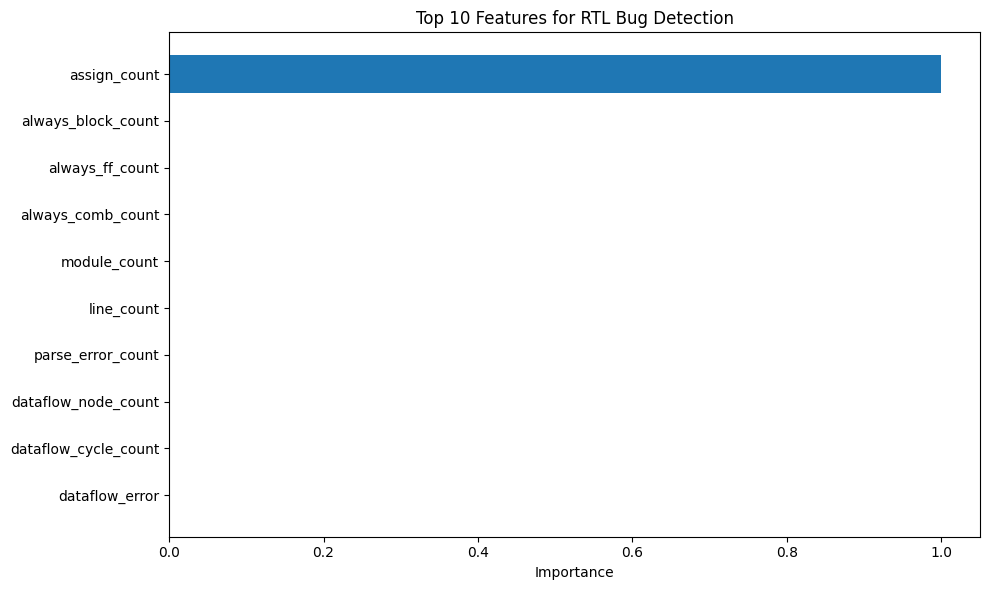

In [39]:
# Feature importance
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:10], importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Features for RTL Bug Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [40]:
# Predict on individual files
print("File-level predictions:")
for i, row in df.iterrows():
    features = row[feature_cols].values.reshape(1, -1)
    pred = clf.predict(features)[0]
    proba = clf.predict_proba(features)[0]
    actual = row['label']
    status = '✓' if (pred == 1 and actual == 'buggy') or (pred == 0 and actual == 'clean') else '✗'
    print(f"{status} {row['file']}: pred={'buggy' if pred==1 else 'clean'} (p={proba[1]:.2f}), actual={actual}")

File-level predictions:
✓ buggy_cdc.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_sensitivity.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_empty_always.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_combo_loop.v: pred=buggy (p=0.57), actual=buggy
✓ buggy_multi_driver.v: pred=buggy (p=0.57), actual=buggy
✓ buggy_parse_error.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_counter.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_unused.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_multi_case.v: pred=buggy (p=0.59), actual=buggy
✓ buggy_fsm_unreachable.v: pred=buggy (p=0.59), actual=buggy
✗ clean_cdc_synced.v: pred=buggy (p=0.59), actual=clean
✗ clean_fsm.v: pred=buggy (p=0.57), actual=clean
✗ clean_literal_assign.v: pred=buggy (p=0.57), actual=clean
✗ clean_latch_default_at_top.v: pred=buggy (p=0.59), actual=clean
✗ clean_branch_split_feedback.v: pred=buggy (p=0.59), actual=clean
✗ clean_multi_module_alias.v: pred=buggy (p=0.57), actual=clean
✗ clean_registered_feedback.v: pred=buggy (p=0.59), actua

## Summary

- **Dataset**: {len(df)} RTL files (buggy + clean)
- **Features**: {len(feature_cols)} AST-based features
- **Model**: XGBoost with GPU acceleration
- **Accuracy**: To be filled after execution

## Next: Task 3 - Security Vulnerability Detection